In [39]:
# Exploratory Data Analysis on Diwali Sales Dataset

## Objective: To analyze customer behavior, product performance, and regional sales trends.

In [ ]:
# import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [40]:
# Load datasets

df = pd.read_csv(r"C:\Users\amans\Downloads\Diwali Sales Data.csv", encoding='unicode_escape')
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [12]:
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


In [41]:
# Basic Information 

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


In [42]:
# Data Cleaning 

# Drop unnecessary columns
df.drop(['Status', 'unnamed1'], axis=1, inplace=True, errors='ignore')

# Rename columns
df.rename(columns={'Marital_Status': 'Married'}, inplace=True)

# Check missing values
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Married              0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [43]:
# Handling missing and duplicates

# Remove null values
df.dropna(inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [48]:
# Preprocessing

# Convert Amount to integer
df['Amount'] = df['Amount'].astype(int)

# Remove outliers
df = df[df['Amount'] < 100000]

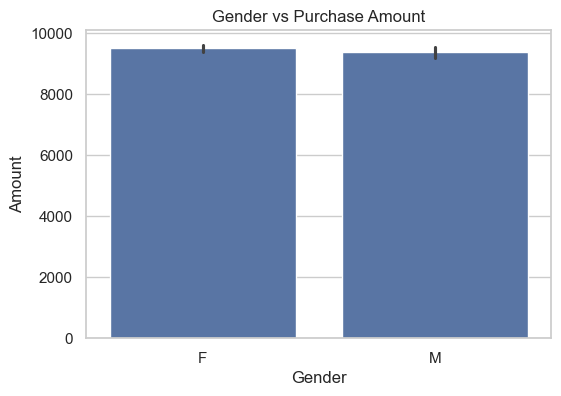

In [23]:
# EDA visualization

# Gender - wise Purchases

plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Amount', data=df)
plt.title("Gender vs Purchase Amount")
plt.show()

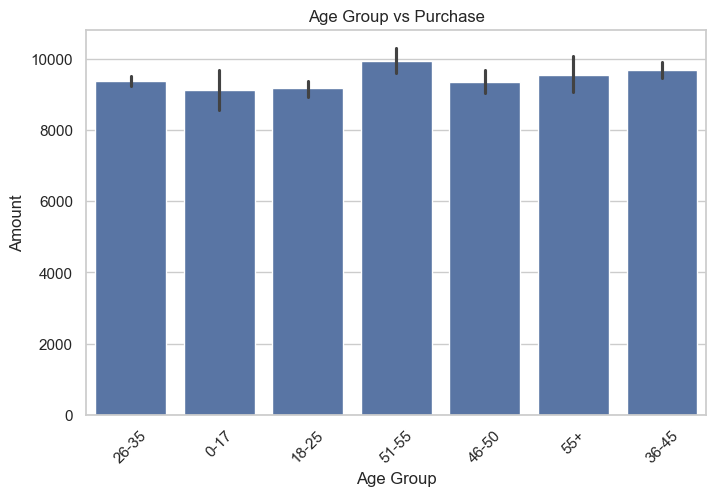

In [24]:
# Age group  vs Purchase

plt.figure(figsize=(8,5))
sns.barplot(x='Age Group', y='Amount', data=df)
plt.title("Age Group vs Purchase")
plt.xticks(rotation=45)
plt.show()

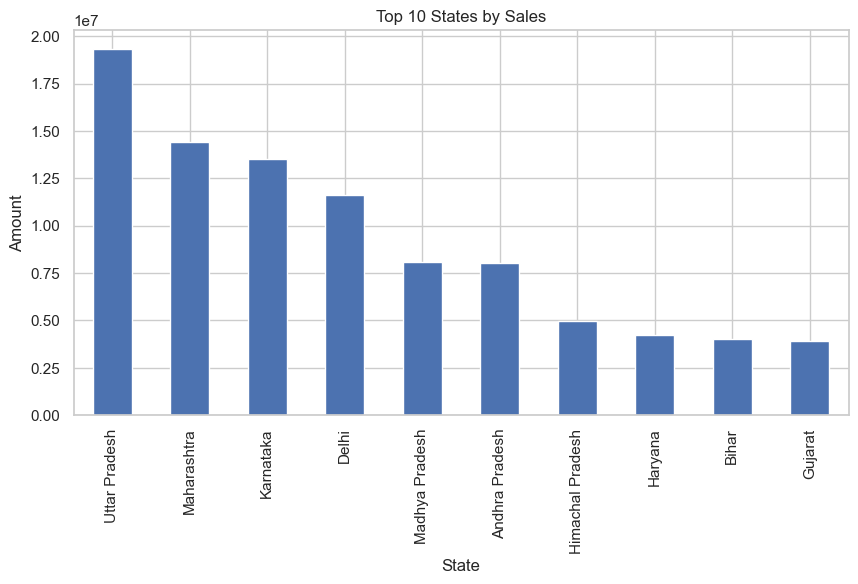

In [25]:
# State Wise Sales 

state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)

state_sales.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Amount")
plt.show()

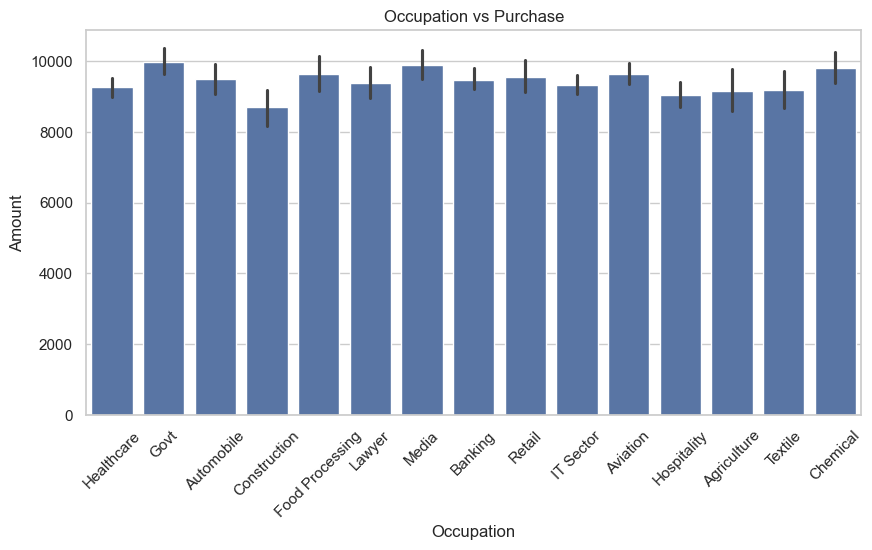

In [26]:
# Occupation vs Purchase

plt.figure(figsize=(10,5))
sns.barplot(x='Occupation', y='Amount', data=df)
plt.title("Occupation vs Purchase")
plt.xticks(rotation=45)
plt.show()

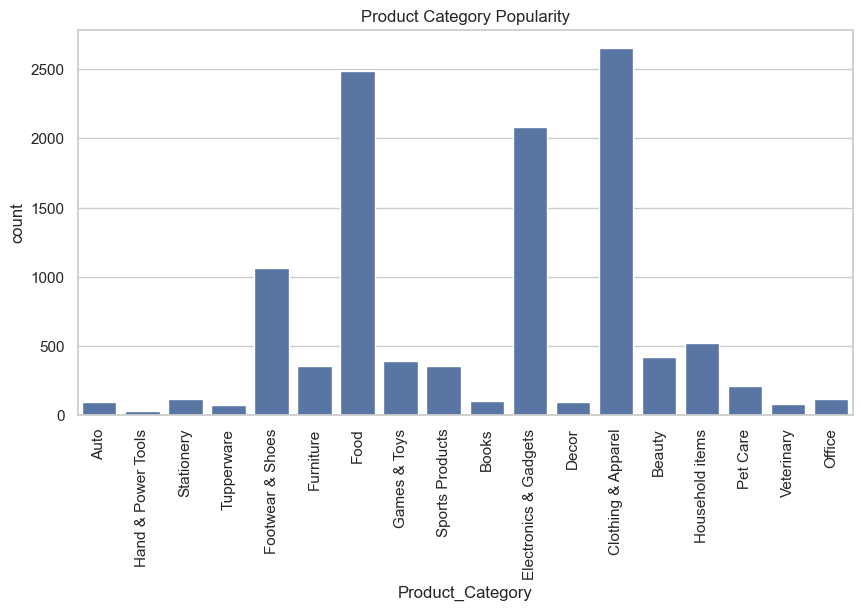

In [27]:
# Product Category

plt.figure(figsize=(10,5))
sns.countplot(x='Product_Category', data=df)
plt.title("Product Category Popularity")
plt.xticks(rotation=90)
plt.show()


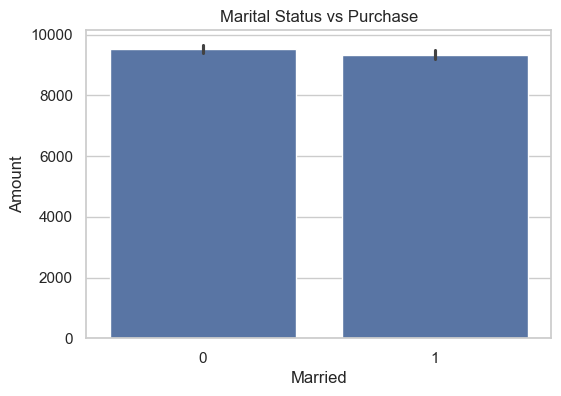

In [28]:
# Martial Status vs Purchase 

plt.figure(figsize=(6,4))
sns.barplot(x='Married', y='Amount', data=df)
plt.title("Marital Status vs Purchase")
plt.show()

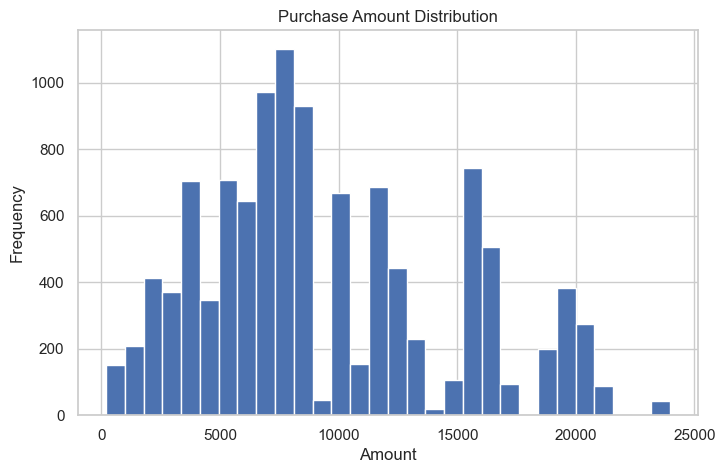

In [31]:
# Histogram 

plt.figure(figsize=(8,5))
plt.hist(df['Amount'], bins=30)
plt.title("Purchase Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

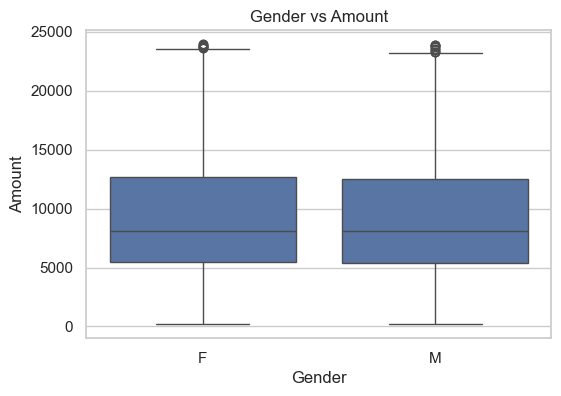

In [32]:
# Boxplot 

plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='Amount', data=df)
plt.title("Gender vs Amount")
plt.show()

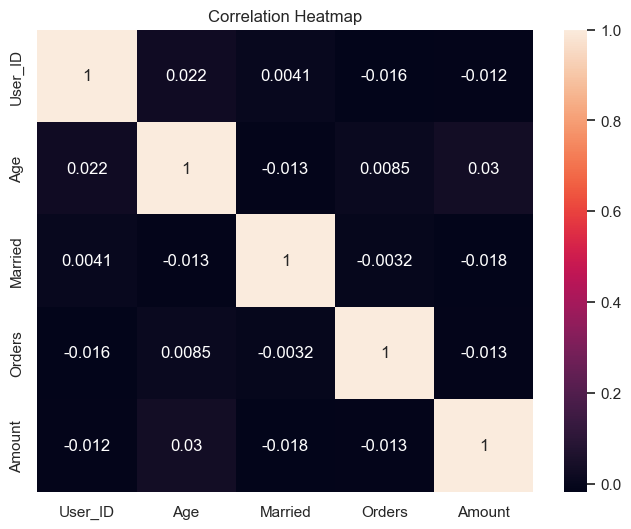

In [33]:
# Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [34]:
df.to_csv(r"C:\Users\amans\Downloads\diwali_cleaned.csv", index=False)

print("✅ File saved successfully!")

✅ File saved successfully!
